In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import pandas as pd

from src.kinetics_model import solve_kinetics, calculate_conversion

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [3]:
# Load experimental data
df = pd.read_csv('../data/experimental_data.csv')

# Split by temperature
data_50 = df[df['temperature_c'] == 50]
data_60 = df[df['temperature_c'] == 60]

print("Data loaded successfully")

Data loaded successfully


In [4]:
# Initial concentrations (mol/L)
TG0 = 1.0      # Triglyceride
DG0 = 0.0      # Diglyceride
MG0 = 0.0      # Monoglyceride
GL0 = 0.0      # Glycerol
ME0 = 0.0      # Methyl esters

initial_C = [TG0, DG0, MG0, GL0, ME0]

# Time points
t = np.linspace(0, 60, 100)

print(f"Initial concentrations: TG0 = {TG0} mol/L")
print(f"Maximum possible ME concentration: {3*TG0} mol/L")

Initial concentrations: TG0 = 1.0 mol/L
Maximum possible ME concentration: 3.0 mol/L


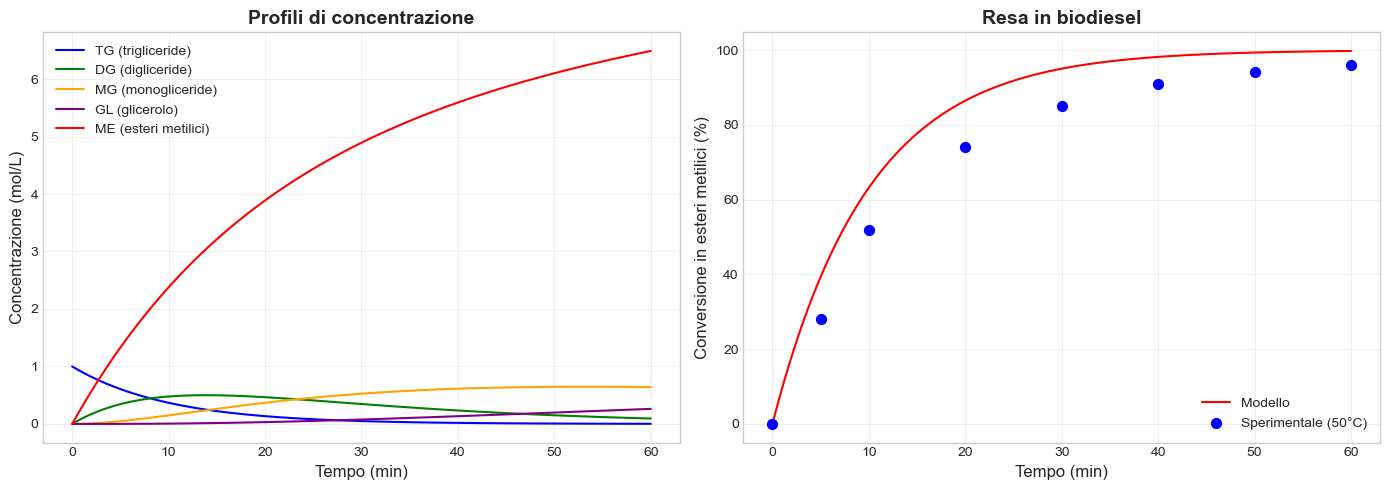

Conversione finale a 60 min: 99.8%
Conversione sperimentale a 60 min (50°C): 96.0%


In [5]:
# Initial guess for kinetic constants
k_test = [0.1, 0.05, 0.01]  # [k1, k2, k3]

# Solve system
solution = solve_kinetics(initial_C, t, k_test)

# Calculate conversion
conversion = calculate_conversion(solution)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Concentration profiles
ax1.plot(t, solution[:, 0], 'b-', label='TG (trigliceride)')
ax1.plot(t, solution[:, 1], 'g-', label='DG (digliceride)')
ax1.plot(t, solution[:, 2], 'orange', label='MG (monogliceride)')
ax1.plot(t, solution[:, 3], 'purple', label='GL (glicerolo)')
ax1.plot(t, solution[:, 4], 'r-', label='ME (esteri metilici)')
ax1.set_xlabel('Tempo (min)', fontsize=12)
ax1.set_ylabel('Concentrazione (mol/L)', fontsize=12)
ax1.set_title('Profili di concentrazione', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Conversion
ax2.plot(t, conversion, 'r-', label='Modello')
ax2.scatter(data_50['time_min'], data_50['conversion'] * 100, 
            color='blue', s=50, zorder=5, label='Sperimentale (50°C)')
ax2.set_xlabel('Tempo (min)', fontsize=12)
ax2.set_ylabel('Conversione in esteri metilici (%)', fontsize=12)
ax2.set_title('Resa in biodiesel', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/kinetics_test_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Conversione finale a 60 min: {conversion[-1]:.1f}%")
print(f"Conversione sperimentale a 60 min (50°C): {data_50[data_50['time_min']==60]['conversion'].values[0]*100:.1f}%")